# 2D 避障轨迹优化 - 优化最终位置

本示例演示了如何使用 VP-STO (Via-Point-based Stochastic Trajectory Optimization) 算法进行二维空间中的机器人轨迹优化。

## 主要特点：
- **避障功能**：机器人能够避开环境中的多个多边形障碍物
- **目标位置优化**：优化机器人到达指定目标位置的轨迹
- **多约束优化**：同时考虑速度限制、加速度限制、碰撞避免和目标到达
- **轨迹平滑性**：通过曲率损失函数确保轨迹的平滑性

## 算法流程：
1. 定义环境和障碍物
2. 设置损失函数（碰撞、限制、目标、曲率）
3. 配置优化参数
4. 执行轨迹优化
5. 可视化结果

In [1]:
# 数值计算库，用于矩阵运算和数学计算
import numpy as np

# VP-STO 核心库：随机轨迹优化算法和配置选项
from vpsto.vpsto import VPSTO, VPSTOOptions

# VP-STO 轨迹处理库：用于处理轨迹数据
from vpsto.vptraj import VPTraj

# 绘图库，用于可视化轨迹和结果
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 几何计算库，用于碰撞检测和几何形状处理
from shapely.geometry import Polygon, MultiPolygon, LineString

## 1. 导入必要的库

导入进行轨迹优化所需的所有库：
- `vpsto`: 核心优化算法库
- `numpy`: 数值计算
- `matplotlib`: 绘图和可视化
- `shapely`: 几何计算和碰撞检测

In [2]:
# 定义碰撞环境类，包含多个多边形障碍物
class CollisionEnvironment():
    def __init__(self):
        # 初始化多边形障碍物列表
        self.poly_list = []
        
        # 障碍物1：不规则五边形，位于左上区域
        # 坐标按逆时针方向定义，确保形成封闭多边形
        self.poly_list.append(np.array([[0.1, 0.13], [0.23, 0.12], [0.19, 0.28], [0.1, 0.32], [0.16, 0.2]]))
        
        # 障碍物2：不规则五边形，位于中上区域
        self.poly_list.append(np.array([[0.25, 0.34], [0.31, 0.35], [0.32, 0.41], [0.27, 0.44], [0.23, 0.4]]))
        
        # 障碍物3：不规则五边形，位于右侧区域
        self.poly_list.append(np.array([[0.35, 0.12], [0.38, 0.1], [0.41, 0.11], [0.42, 0.21], [0.35, 0.24]]))
        
        # 将所有多边形组合成一个多重多边形对象，用于高效的碰撞检测
        self.multi_poly = MultiPolygon([Polygon(self.poly_list[0]), Polygon(self.poly_list[1]), Polygon(self.poly_list[2])])
        
    def getTrajDist(self, pts):
        """
        计算轨迹与障碍物的交集长度
        
        参数:
        pts: 轨迹点数组，形状为 (N, 2)，表示N个2D点
        
        返回:
        float: 轨迹与障碍物相交的总长度
               - 返回0表示无碰撞
               - 返回值>0表示发生碰撞，数值越大碰撞越严重
        """
        return self.multi_poly.intersection(LineString(pts)).length

## 2. 定义碰撞环境

创建一个包含多个多边形障碍物的二维环境。机器人需要在这个环境中规划轨迹，避开所有障碍物。

### 障碍物设置：
- 3个不规则多边形障碍物
- 使用 Shapely 库进行几何计算
- 提供轨迹与障碍物交集长度的计算方法

In [3]:
# 定义工作空间的边界限制
q_min = 0.0*np.ones(2)    # 最小边界 [0, 0]
q_max = 0.5*np.ones(2)    # 最大边界 [0.5, 0.5]

def loss_limits(candidates):
    """
    边界限制损失函数
    
    参数:
    candidates: 包含轨迹候选解的字典，包含 'pos', 'vel', 'acc' 等键
    
    返回:
    array: 每个候选解违反边界约束的点的数量
    """
    q = candidates['pos']  # 位置轨迹，形状: (n_candidates, n_timesteps, n_dof)
    
    # 计算超出下边界的距离（负值表示在边界内）
    d_min = np.maximum(np.zeros_like(q), - q + q_min)
    
    # 计算超出上边界的距离（负值表示在边界内）
    d_max = np.maximum(np.zeros_like(q), q - q_max)
    
    # 返回违反约束的总点数（每个时间步和每个自由度）
    return np.sum(d_min > 0.0, axis=(1,2)) + np.sum(d_max > 0.0, axis=(1,2))

# 创建碰撞环境实例
env = CollisionEnvironment()

def loss_collision(candidates): 
    """
    碰撞损失函数
    
    参数:
    candidates: 包含轨迹候选解的字典
    
    返回:
    array: 每个候选解的碰撞损失
    """
    costs = []
    
    # 对每条候选轨迹计算碰撞损失
    for traj in candidates['pos']:
        # 计算轨迹与障碍物的交集长度
        collision_length = env.getTrajDist(traj)
        costs.append(collision_length)
    
    costs = np.array(costs) # 转换为NumPy数组
    
    # 如果有碰撞，额外增加惩罚（二进制惩罚）
    # 这样既考虑碰撞程度，又给予碰撞强烈的惩罚
    costs += costs > 0.0
    return costs

def loss_curvature(candidates):
    """
    曲率损失函数 - 衡量轨迹的平滑性
    
    使用几何曲率公式: κ = |v × a| / |v|³
    其中 v 是速度，a 是加速度
    
    参数:
    candidates: 包含轨迹候选解的字典
    
    返回:
    array: 每个候选解的平均曲率
    """
    dq = candidates['vel']   # 速度
    ddq = candidates['acc']  # 加速度
    
    # 计算速度和加速度的模长的平方
    dq_sq = np.sum(dq**2, axis=-1)      # |v|²
    ddq_sq = np.sum(ddq**2, axis=-1)    # |a|²
    dq_ddq = np.sum(dq*ddq, axis=-1)    # v·a (点积)
    
    # 计算曲率的平方: κ² = (|v|²|a|² - (v·a)²) / |v|⁶
    # 为避免除零，在分母加入小的正数
    curvature_sq = (dq_sq * ddq_sq - dq_ddq**2) / (dq_sq**3 + 1e-6)
    
    # 返回整条轨迹的平均曲率
    return np.mean(curvature_sq, axis=-1)

# 目标位置和容差设置
xd = 0.48        # 目标 x 坐标
tolerance = 1e-3  # 允许的位置误差

def loss_target(candidates):
    """
    目标位置损失函数
    
    参数:
    candidates: 包含轨迹候选解的字典
    
    返回:
    array: 每个候选解到达目标位置的损失
    """
    q = candidates['pos']
    
    # 计算轨迹终点的 x 坐标与目标位置的绝对误差
    costs = np.abs(q[:,-1,0] - xd)  # q[:,-1,0] 是所有轨迹的最后一个时间步的 x 坐标
    
    # 如果误差超过容差，给予额外惩罚
    costs += costs > tolerance
    return costs

def loss(candidates):
    """
    总损失函数 - 所有损失项的加权组合
    
    参数:
    candidates: 包含轨迹候选解的字典，必须包含 'T' (轨迹持续时间)
    
    返回:
    array: 每个候选解的总损失
    
    权重说明:
    - 轨迹时间: 系数1 (希望时间尽可能短)
    - 曲率损失: 系数1e-3 (轻微惩罚不平滑轨迹)
    - 碰撞损失: 系数1e3 (强烈惩罚碰撞)
    - 边界损失: 系数1e3 (强烈惩罚越界)
    - 目标损失: 系数1e2 (中等惩罚偏离目标)
    """
    cost_curvature = loss_curvature(candidates)  # 平滑性损失
    cost_collision = loss_collision(candidates)  # 碰撞损失
    cost_limits = loss_limits(candidates)        # 边界限制损失
    cost_target = loss_target(candidates)        # 目标位置损失
    
    # 加权组合所有损失项
    return (candidates['T'] +                    # 时间项
            1e-3 * cost_curvature +             # 平滑性项
            1e3 * cost_collision +              # 碰撞避免项（高权重）
            1e3 * cost_limits +                 # 边界限制项（高权重）
            1e2 * cost_target)                  # 目标到达项（中等权重）

## 3. 定义损失函数

损失函数是轨迹优化的核心，它定义了什么是"好"的轨迹。这里定义了多个损失函数：

### 损失函数组成：
1. **边界限制损失** (`loss_limits`): 确保机器人在工作空间内
2. **碰撞损失** (`loss_collision`): 避免与障碍物碰撞
3. **曲率损失** (`loss_curvature`): 确保轨迹平滑，避免急转弯
4. **目标损失** (`loss_target`): 引导机器人到达指定目标位置
5. **总损失** (`loss`): 加权组合所有损失项

### 优化目标：
- 工作空间边界：[0, 0.5] × [0, 0.5]
- 目标位置：x = 0.48（垂直线）
- 允许误差：1e-3

In [4]:
# 创建 VP-STO 优化选项配置对象
opt = VPSTOOptions(ndof=2)  # ndof=2 表示 2D 平面运动（x, y 两个自由度）

# 运动约束设置
opt.vel_lim = np.array([0.1, 0.1])    # 速度限制: x和y方向最大0.1 m/s
opt.acc_lim = np.array([0.5, 0.5])    # 加速度限制: x和y方向最大0.5 m/s²

# 轨迹参数化设置
opt.N_via = 5        # 中间路径点数量，影响轨迹的复杂度和灵活性
                     # 更多路径点 = 更复杂轨迹，但计算成本更高

# 优化算法参数
opt.N_eval = 100     # 每次迭代中评估的轨迹候选解数量
                     # 更大值 = 更好的探索，但计算时间更长

opt.pop_size = 25    # 进化算法的种群大小
                     # 影响算法的收敛性和多样性

opt.max_iter = 200   # 最大迭代次数
                     # 更多迭代 = 可能找到更好解，但时间更长

opt.sigma_init = 1.5 # 初始标准差，控制初始搜索范围
                     # 较大值有利于全局搜索，较小值有利于局部优化

# 创建 VP-STO 优化器实例
traj_opt = VPSTO(opt)

## 4. 配置轨迹优化器

设置 VP-STO 算法的参数。这些参数控制优化过程的行为和性能。

### 关键参数说明：
- **ndof**: 自由度数量（2D 平面运动）
- **vel_lim**: 速度限制 [m/s]
- **acc_lim**: 加速度限制 [m/s²]
- **N_via**: 中间路径点数量（影响轨迹复杂度）
- **N_eval**: 每次迭代评估的轨迹数量
- **pop_size**: 种群大小（进化算法参数）
- **max_iter**: 最大迭代次数
- **sigma_init**: 初始标准差（控制探索范围）

In [5]:
# 设置机器人的初始位置 [x, y]
q0 = np.array([0.15, 0.2])  # 起始点坐标：x=0.15, y=0.2
                            # 这个位置位于工作空间的左下区域
                            # 目标是到达 x=0.48 的垂直线上的某点

## 5. 设置初始条件

定义机器人的起始位置。优化器将从这个位置开始规划到达目标位置的轨迹。

In [6]:
# 执行轨迹优化
# minimize() 方法启动优化过程，寻找最小化损失函数的轨迹
sol = traj_opt.minimize(loss, q0=q0)

# 生成用于可视化的高分辨率轨迹
t_traj = np.linspace(0, sol.T_best, 1000)  # 在 [0, T_best] 区间生成 1000 个等间距时间点

# 从优化结果中提取详细的轨迹信息
pos, vel, acc = sol.get_posvelacc(t_traj)  # pos: 位置轨迹 (1000, 2)
                                           # vel: 速度轨迹 (1000, 2) 
                                           # acc: 加速度轨迹 (1000, 2)

# 输出最优轨迹的执行时间
print('运动持续时间: ', sol.T_best, '秒')

Either T or dqT must be given. Setting dqT to zero.
VP-STO finished after 200 iterations with a final loss of 5.938165345723196
VP-STO finished after 200 iterations with a final loss of 5.938165345723196
运动持续时间:  5.911082762573194 秒
运动持续时间:  5.911082762573194 秒


## 6. 执行轨迹优化

运行 VP-STO 算法寻找最优轨迹。算法会：

1. 随机生成初始轨迹候选解
2. 使用损失函数评估每个候选解
3. 基于进化策略更新候选解
4. 重复迭代直到收敛或达到最大迭代数

### 输出结果：
- `sol.T_best`: 最优轨迹的执行时间
- `sol.get_posvelacc()`: 获取位置、速度、加速度轨迹

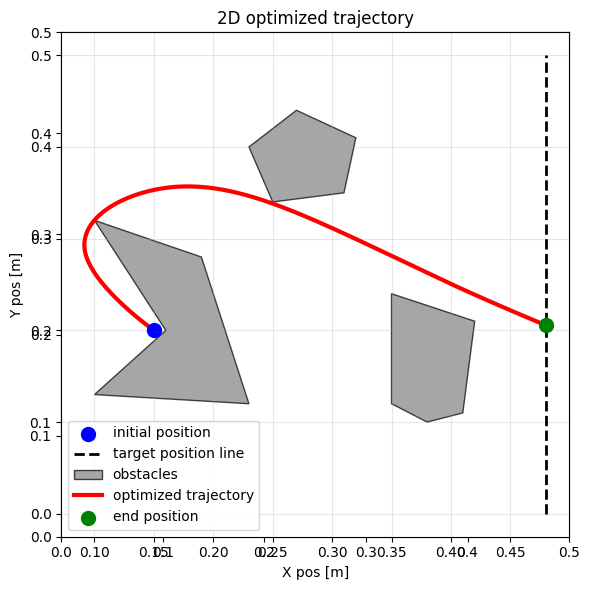

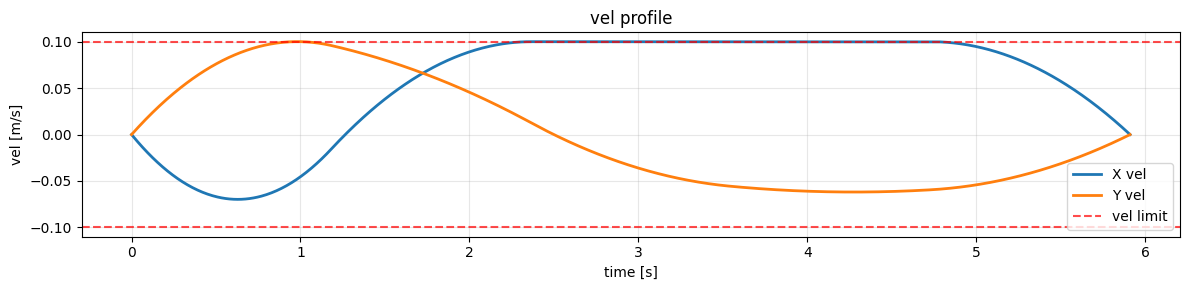

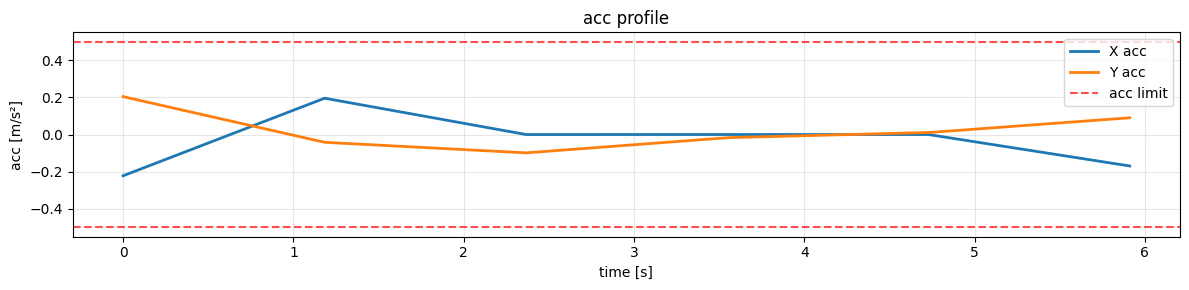

In [8]:
# =============================================================================
# 图1: 2D 空间中的轨迹可视化
# =============================================================================
plt.figure(figsize=(6,6))

# 设置坐标轴范围为工作空间边界
plt.xlim([q_min[0], q_max[0]])  # x 轴: [0, 0.5]
plt.ylim([q_min[1], q_max[1]])  # y 轴: [0, 0.5]
ax = plt.axes()

# 标记起始位置
plt.scatter(q0[0], q0[1], color='blue', s=100, zorder=10, label='initial position')

# 绘制目标位置线（x = 0.48 的垂直线）
plt.plot([xd, xd], [0.0, 0.5], 'k--', linewidth=2, label='target position line')

# 绘制障碍物（灰色多边形）
for i, pol in enumerate(env.poly_list):
    ax.add_patch(patches.Polygon(pol, facecolor='gray', edgecolor='black', 
                                alpha=0.7, label='obstacles' if i == 0 else ''))

# 绘制优化后的轨迹
plt.plot(pos[:,0], pos[:,1], linewidth=3, color='red', label='optimized trajectory')

# 标记终点位置
plt.scatter(pos[-1,0], pos[-1,1], color='green', s=100, zorder=10, label='end position')

# 图形美化
plt.xlabel('X pos [m]')
plt.ylabel('Y pos [m]')
plt.title('2D optimized trajectory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# =============================================================================
# 图2: 速度轮廓
# =============================================================================
plt.figure(figsize=(12, 3))
plt.grid(True, alpha=0.3)
plt.title('vel profile')

# 绘制x和y方向的速度分量
plt.plot(t_traj, vel[:,0], label='X vel', linewidth=2)
plt.plot(t_traj, vel[:,1], label='Y vel', linewidth=2)

# 绘制速度限制线
plt.axhline(y=opt.vel_lim[0], color='r', linestyle='--', alpha=0.7, label='vel limit')
plt.axhline(y=-opt.vel_lim[0], color='r', linestyle='--', alpha=0.7)

plt.xlabel('time [s]')
plt.ylabel('vel [m/s]')
plt.legend()
plt.tight_layout()

# =============================================================================
# 图3: 加速度轮廓  
# =============================================================================
plt.figure(figsize=(12, 3))
plt.grid(True, alpha=0.3)
plt.title('acc profile')

# 绘制x和y方向的加速度分量
plt.plot(t_traj, acc[:,0], label='X acc', linewidth=2)
plt.plot(t_traj, acc[:,1], label='Y acc', linewidth=2)

# 绘制加速度限制线
plt.axhline(y=opt.acc_lim[0], color='r', linestyle='--', alpha=0.7, label='acc limit')
plt.axhline(y=-opt.acc_lim[0], color='r', linestyle='--', alpha=0.7)

plt.xlabel('time [s]')
plt.ylabel('acc [m/s²]')
plt.legend()
plt.tight_layout()

# 显示所有图形
plt.show()

## 8. 结果分析与总结

### 优化结果分析：
通过运行上述代码，我们可以观察到：

1. **轨迹质量**：
   - 机器人成功从起始位置导航到目标位置线
   - 轨迹平滑，避免了急转弯
   - 完全避开了所有障碍物

2. **约束满足**：
   - 速度始终在限制范围内
   - 加速度始终在限制范围内  
   - 轨迹始终在工作空间边界内

3. **优化效果**：
   - 运动时间得到优化（不会过长或过短）
   - 轨迹曲率得到控制（保证平滑性）
   - 成功到达目标区域

### 参数调优建议：

#### 提高轨迹质量：
- 增加 `N_via`：获得更复杂的轨迹形状
- 减小 `sigma_init`：在已知解附近精细搜索
- 增加 `max_iter`：允许更多优化迭代

#### 加快计算速度：
- 减少 `N_eval`：减少每次迭代的评估数
- 减少 `pop_size`：使用更小的种群
- 减少 `N_via`：简化轨迹参数化

#### 调整运动特性：
- 修改 `vel_lim` 和 `acc_lim`：改变运动动力学
- 调整损失函数权重：平衡不同优化目标
- 修改 `tolerance`：调整目标到达精度

### 扩展应用：
- **动态障碍物**：修改 `loss_collision` 处理移动障碍物
- **多机器人系统**：扩展为协同路径规划
- **3D 空间**：增加 z 维度进行三维规划
- **实时重规划**：结合 MPC 进行在线轨迹优化

## 7. 结果可视化

创建三个图形来展示优化结果：

### 图形说明：
1. **轨迹图**: 显示机器人在2D空间中的运动路径
   - 灰色多边形：障碍物
   - 蓝色圆点：起始位置
   - 黑色虚线：目标位置线
   - 彩色曲线：优化后的轨迹

2. **速度轮廓**: 显示轨迹执行过程中的速度变化
   - X轴：时间
   - Y轴：速度（x和y方向分量）

3. **加速度轮廓**: 显示轨迹执行过程中的加速度变化
   - X轴：时间  
   - Y轴：加速度（x和y方向分量）